*Data From Kaggle:* kaggle.com/datasets/imakash3011/customer-personality-analysis

Principal Component Analysis (PCA) is a dimentionality reduction twchnique used to transform a dataset with many correlated variables into a smaller set of new, uncorrelated variables, called principal components. while retaining as much information (variance) as possible. In other words, PCA reduces complexity without losing the essence of the data. In real world datasets, there are often many features, and many features are correlated. PCA helps by reducing the numbersof features, removing redundancy, improving computational efficiency, and making data easier to visualize and analyze. Principal components are new variables created from the original features. 
PCA is scale sensetive, so features must be on the same scale. PCA finds new axes where the data varies the most. The data is expressed in terms of principal components.

Limitations of pca:
- Principal components maybe hard to interpret
- PCA assumes linear relationships
- Important but low-variance features may be lost
- PCA does not consider the target variable (unsupervised)

Essentially, PCA transforms correlated, high-dimentional data into a smaller set of meaningful components that capture most of the data's variance.

In [1]:
#Load data.
import pandas as pd
data = pd.read_csv('C:/Users/hasna/Downloads/marketing_campaign.csv', sep='\t')
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [2]:
#Let's check the info.
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [3]:
#Let's calculate the age of the customers:

#Convert customer date to datetime.
data['Dt_Customer'] = pd.to_datetime(data['Dt_Customer'], format='%d-%m-%Y')
#Extract year from customer date.
data['Customer_Year'] = data['Dt_Customer'].dt.year
#calculate age
data['Age'] = data['Customer_Year'] - data['Year_Birth']

data.head()
#Age has been added to the last column.

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Customer_Year,Age
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,0,0,0,0,3,11,1,2012,55
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,0,0,0,0,3,11,0,2014,60
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,0,0,0,0,3,11,0,2013,48
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,0,0,0,0,3,11,0,2014,30
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,0,0,0,0,3,11,0,2014,33


In [4]:
#Drop the unnecessary columns from the dataset.
data = data.drop(labels=['ID', 'Year_Birth', 'Dt_Customer', 'Customer_Year'], axis=1)

In [5]:
#Converting categorical data into numerical data.
import numpy as np
data = pd.get_dummies(data, columns=['Education', 'Marital_Status'], dtype=np.int64)
data.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,Education_Master,Education_PhD,Marital_Status_Absurd,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,0,0,0,0,0,1,0,0,0
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,0,0,0,0,0,1,0,0,0
2,71613.0,0,0,26,426,49,127,111,21,42,...,0,0,0,0,0,0,0,1,0,0
3,26646.0,1,0,26,11,4,20,10,3,5,...,0,0,0,0,0,0,0,1,0,0
4,58293.0,1,0,94,173,43,118,46,27,15,...,0,1,0,0,0,1,0,0,0,0


In [6]:
#Let's check if we have any empty cell in the dataset.
data.isnull().sum()

Income                     24
Kidhome                     0
Teenhome                    0
Recency                     0
MntWines                    0
MntFruits                   0
MntMeatProducts             0
MntFishProducts             0
MntSweetProducts            0
MntGoldProds                0
NumDealsPurchases           0
NumWebPurchases             0
NumCatalogPurchases         0
NumStorePurchases           0
NumWebVisitsMonth           0
AcceptedCmp3                0
AcceptedCmp4                0
AcceptedCmp5                0
AcceptedCmp1                0
AcceptedCmp2                0
Complain                    0
Z_CostContact               0
Z_Revenue                   0
Response                    0
Age                         0
Education_2n Cycle          0
Education_Basic             0
Education_Graduation        0
Education_Master            0
Education_PhD               0
Marital_Status_Absurd       0
Marital_Status_Alone        0
Marital_Status_Divorced     0
Marital_St

In [7]:
#There are 24 empty cell in the Income column. Let's fill the empty cells with the average income.
import numpy as np
data['Income'] = data['Income'].fillna(np.mean(data['Income']))

#Let's check again:
data.isnull().sum()

Income                     0
Kidhome                    0
Teenhome                   0
Recency                    0
MntWines                   0
MntFruits                  0
MntMeatProducts            0
MntFishProducts            0
MntSweetProducts           0
MntGoldProds               0
NumDealsPurchases          0
NumWebPurchases            0
NumCatalogPurchases        0
NumStorePurchases          0
NumWebVisitsMonth          0
AcceptedCmp3               0
AcceptedCmp4               0
AcceptedCmp5               0
AcceptedCmp1               0
AcceptedCmp2               0
Complain                   0
Z_CostContact              0
Z_Revenue                  0
Response                   0
Age                        0
Education_2n Cycle         0
Education_Basic            0
Education_Graduation       0
Education_Master           0
Education_PhD              0
Marital_Status_Absurd      0
Marital_Status_Alone       0
Marital_Status_Divorced    0
Marital_Status_Married     0
Marital_Status

In [8]:
#Standardize data.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

In [9]:
#Apply PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=18, random_state=1)
pca = pca.fit_transform(scaled_data)

pca_data = pd.DataFrame(data=pca, columns=['PC_1', 'PC_2', 'PC_3','PC_4', 'PC_5',
                                           'PC_6', 'PC_7', 'PC_8', 'PC_9','PC_10',
                                           'PC_11', 'PC_12', 'PC_13', 'PC_14', 'PC_15',
                                           'PC_16', 'PC_17', 'PC_18'])

pca_data.head()

,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,PC_10,PC_11,PC_12,PC_13,PC_14,PC_15,PC_16,PC_17,PC_18
0,3.784442,-1.134745,-0.352825,1.608288,-0.909525,2.185540,-1.050129,0.420860,-0.358489,-0.285766,0.376788,-0.161355,-0.268181,-0.043923,-0.157759,-0.367140,0.118359,-0.465656
1,-2.320539,-0.370135,-0.311592,0.424656,-1.187974,-0.329945,-1.895651,0.860695,0.099478,-0.109356,0.149154,-0.946454,-0.183948,0.188961,0.100067,-0.409175,-0.483043,0.937790
2,1.654464,-0.380098,-1.370269,0.043170,-1.364966,-0.617626,0.683638,-0.657261,-0.260169,-0.852077,-0.107590,-0.374973,0.870158,-0.350357,-0.085492,0.049972,-0.857987,-0.012561
3,-2.456988,-1.458513,-0.070132,0.445112,-1.300485,-0.827235,0.950124,-0.683180,-0.281112,-0.904619,-0.343658,-0.428572,0.752843,-0.059319,0.206087,-0.417921,-0.195980,-0.666558
4,-0.458686,0.372944,-0.124815,-0.634281,1.919224,0.333389,-0.231166,-0.835485,-1.488009,-0.061636,-0.770669,0.877454,-0.782628,0.558233,0.470942,-0.278395,1.135186,-1.397791


In [10]:
from sklearn.decomposition import PCA
pca = PCA(n_components=18, random_state=1)
data_pca = pca.fit_transform(scaled_data)

for i in range(0, len(pca.explained_variance_ratio_)):
    print(f'Principal component {i}: {pca.explained_variance_ratio_[i]}')

Principal component 0: 0.1819889460069419
Principal component 1: 0.06098044416405787
Principal component 2: 0.05456549162033283
Principal component 3: 0.045804126206309186
Principal component 4: 0.04228260208940964
Principal component 5: 0.039931878106071676
Principal component 6: 0.03660816051251109
Principal component 7: 0.03405238820798171
Principal component 8: 0.03338157149176633
Principal component 9: 0.03210798099903725
Principal component 10: 0.030054713788321464
Principal component 11: 0.029335115412950606
Principal component 12: 0.029003109159352097
Principal component 13: 0.028227379980987854
Principal component 14: 0.027699411738010653
Principal component 15: 0.02691923735797008
Principal component 16: 0.026061362614024867
Principal component 17: 0.025684642986006985


---
Scree Plot
-

A scree plot is a simple graph used in PCA to decide how many principal components to keep.
In geology, scree means loose rocks piling up at the bottom of a cliff.
In PCA, after a certain point, components contribute very little useful variance — they are like those loose rocks.

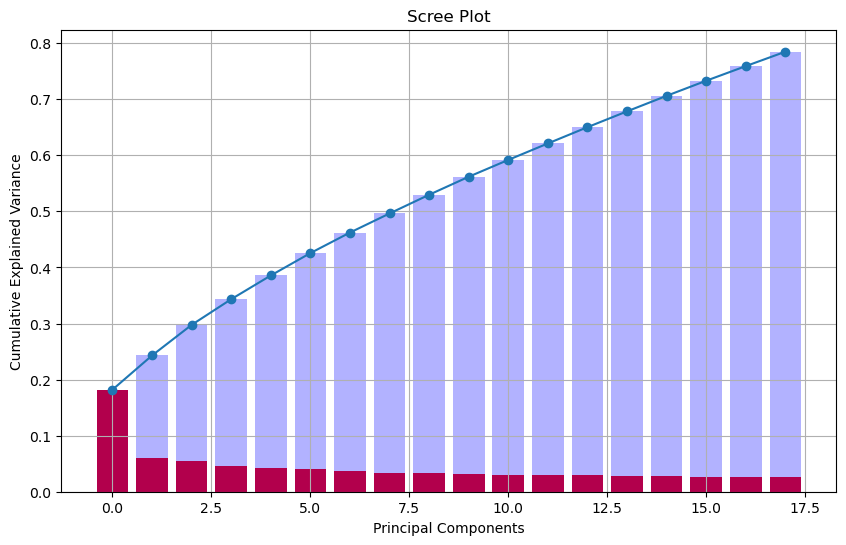

In [12]:
import matplotlib.pyplot as plt

cum_var_exp = np.cumsum(pca.explained_variance_ratio_)
PCs = range(pca.n_components_)

plt.figure(figsize=(10, 6))
plt.bar(PCs, pca.explained_variance_ratio_, color='red')
plt.bar(PCs, cum_var_exp, color='blue', alpha=0.3)
plt.plot(PCs, cum_var_exp, marker='o')
plt.grid()
plt.xlabel('Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot')
plt.show()